# 09_reduced_fwi_baseline.ipynb

Reduced FWI baseline для задачи **sensor -> speed map**.

## Идея
Мы решаем классическую инверсную задачу в частотной постановке:

\[
\min_c \; \| (F(c)-M_{hom}) - (M-M_{hom}) \|^2 + \lambda_{l2} R_{l2}(c) + \lambda_{smooth} R_{smooth}(c)
\]

где:
- `F(c)` — forward solver,
- `M` — измеренная measurement matrix,
- `M_hom` — ответ однородной среды,
- `R_l2`, `R_smooth` — регуляризация.

## Почему reduced
Полный FWI слишком дорогой, поэтому здесь:
- используется **residual objective**;
- берётся **subset of sources**;
- оптимизация идёт в **coarse-to-fine** режиме;
- карта параметризуется через low-resolution latent `z`;
- есть опциональная инициализация от **CNN checkpoint**.

## Что это даёт
Это не industrial-grade FWI, а **честный classical baseline**, который можно сравнить с CNN / DeepONet / FNO на небольшом subset test-примеров.

## 0. Важно про JAX
Эта ячейка должна выполняться **до любого `import jax`**.

По умолчанию ноутбук настроен на **CPU**, чтобы избежать ошибок `cuFFT / XlaRuntimeError`.
Если захочешь попробовать GPU, поменяй `JAX_PLATFORMS` до перезапуска kernel.

In [1]:
import os

os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"] = "platform"
os.environ.pop("LD_LIBRARY_PATH", None)

'/usr/local/nvidia/lib:/usr/local/nvidia/lib64:/usr/local/cuda/lib64'

In [2]:
import time
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import jit, value_and_grad
from jax.image import resize

from jwave import FourierSeries
from jwave.geometry import Domain, Medium
from jwave.acoustics.time_harmonic import helmholtz_solver

print("jax version:", jax.__version__)
print("jax devices:", jax.devices())

jax version: 0.4.38
jax devices: [CudaDevice(id=0)]


In [3]:
OUT_ROOT = Path("/workspace/usct_dataset_v2")
TEST_DIR = OUT_ROOT / "test"
assert TEST_DIR.exists(), TEST_DIR

test_files = sorted(TEST_DIR.glob("*.npz"))
print("test:", len(test_files))
assert len(test_files) > 0

CNN_CKPT_PATH = Path("/workspace/reference_points/baseline_residual_v2_main/baseline_model.pt")
print("cnn checkpoint exists:", CNN_CKPT_PATH.exists())

test: 800
cnn checkpoint exists: True


In [4]:
CFG = {
    "background_speed": 1500.0,
    "density": 1000.0,
    "pml_size": 16,
    "source_sigma_px": 1.8,
    "mask_half_width": 4,
    "source_subset_mode": "uniform",
    "num_sources_used": 8,
    "amplitude_limit": 90.0,
    "lambda_l2": 5e-4,
    "lambda_smooth": 5e-2,
    "init_mode": "homogeneous",
    "num_examples_to_run": 3,
    "example_indices_from_test": [0, 1, 2],
    "stages": [
        {"lowres_h": 16, "lowres_w": 16, "num_steps": 120, "lr": 0.08},
        {"lowres_h": 24, "lowres_w": 24, "num_steps": 140, "lr": 0.05},
        {"lowres_h": 32, "lowres_w": 32, "num_steps": 180, "lr": 0.03},
    ],
    "beta1": 0.9,
    "beta2": 0.999,
    "adam_eps": 1e-8,
    "save_run_name": "reduced_fwi_baseline_v1",
}
CFG

{'background_speed': 1500.0,
 'density': 1000.0,
 'pml_size': 16,
 'source_sigma_px': 1.8,
 'mask_half_width': 4,
 'source_subset_mode': 'uniform',
 'num_sources_used': 8,
 'amplitude_limit': 90.0,
 'lambda_l2': 0.0005,
 'lambda_smooth': 0.05,
 'init_mode': 'homogeneous',
 'num_examples_to_run': 3,
 'example_indices_from_test': [0, 1, 2],
 'stages': [{'lowres_h': 16, 'lowres_w': 16, 'num_steps': 120, 'lr': 0.08},
  {'lowres_h': 24, 'lowres_w': 24, 'num_steps': 140, 'lr': 0.05},
  {'lowres_h': 32, 'lowres_w': 32, 'num_steps': 180, 'lr': 0.03}],
 'beta1': 0.9,
 'beta2': 0.999,
 'adam_eps': 1e-08,
 'save_run_name': 'reduced_fwi_baseline_v1'}

file: /workspace/usct_dataset_v2/test/sample_00000.npz
keys: ['x', 'c', 'receiver_y', 'receiver_x', 'source_ring_idx', 'dx', 'freq_hz']
x                shape=(2, 16, 256) dtype=float32
c                shape=(192, 192) dtype=float32
receiver_y       shape=(256,) dtype=int64
receiver_x       shape=(256,) dtype=int64
source_ring_idx  shape=(16,) dtype=int64
dx               shape=(2,) dtype=float32
freq_hz          shape=(1,) dtype=float32


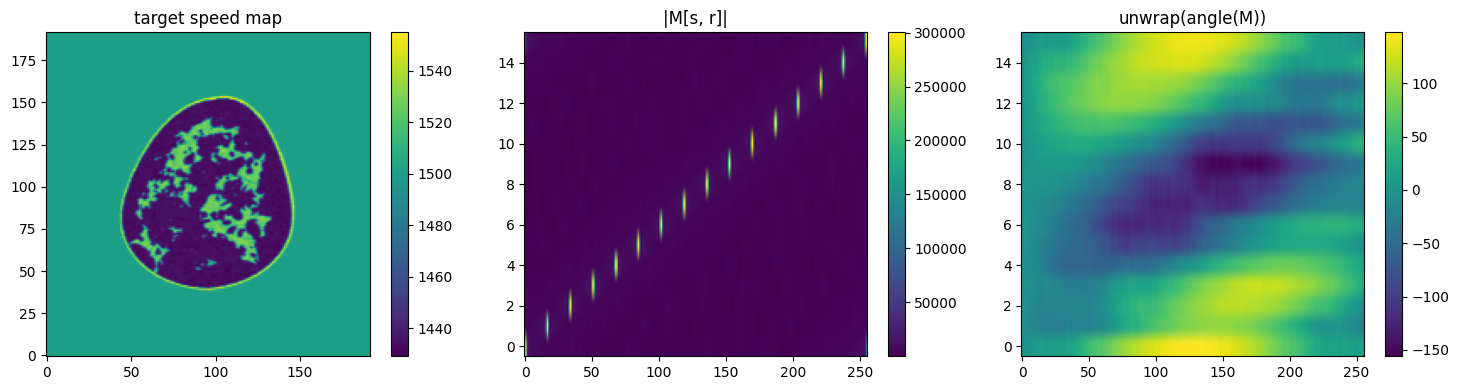

In [5]:
def inspect_npz(path: Path):
    d = np.load(path)
    print("file:", path)
    print("keys:", d.files)
    for k in d.files:
        arr = d[k]
        print(f"{k:16s} shape={arr.shape} dtype={arr.dtype}")

    x = d["x"]
    c = d["c"]
    M = x[0] + 1j * x[1]

    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    im0 = ax[0].imshow(c, origin="lower")
    ax[0].set_title("target speed map")
    plt.colorbar(im0, ax=ax[0])

    im1 = ax[1].imshow(np.abs(M), aspect="auto", origin="lower")
    ax[1].set_title("|M[s, r]|")
    plt.colorbar(im1, ax=ax[1])

    im2 = ax[2].imshow(np.unwrap(np.angle(M), axis=1), aspect="auto", origin="lower")
    ax[2].set_title("unwrap(angle(M))")
    plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()

inspect_npz(test_files[0])

In [6]:
def mse(a, b):
    return float(np.mean((a - b) ** 2))

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

def relative_l2(a, b):
    num = np.linalg.norm(a - b)
    den = np.linalg.norm(b) + 1e-8
    return float(num / den)

def psnr_from_mse(mse_value, data_range):
    if mse_value <= 1e-12:
        return float("inf")
    return float(20 * np.log10(data_range) - 10 * np.log10(mse_value))

try:
    from skimage.metrics import structural_similarity as ssim_fn
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    ssim_fn = None

def compute_metrics(pred, target, data_range):
    out = {
        "mse": mse(pred, target),
        "rmse": rmse(pred, target),
        "relative_l2": relative_l2(pred, target),
        "psnr": psnr_from_mse(mse(pred, target), data_range),
    }
    if HAS_SKIMAGE:
        out["ssim"] = float(ssim_fn(pred, target, data_range=data_range))
    return out

def mask_selected_receivers(num_sources_used, num_receivers, selected_source_ring_idx, half_width=4):
    mask = np.ones((num_sources_used, num_receivers), dtype=np.float32)
    for s in range(num_sources_used):
        ridx = int(selected_source_ring_idx[s])
        for delta in range(-half_width, half_width + 1):
            rr = (ridx + delta) % num_receivers
            mask[s, rr] = 0.0
    return mask

def gaussian_source(H: int, W: int, y0: int, x0: int, sigma: float = 1.8):
    yy, xx = np.mgrid[0:H, 0:W]
    g = np.exp(-((yy - y0) ** 2 + (xx - x0) ** 2) / (2 * sigma**2))
    g = g / g.sum()
    return g.astype(np.float32)

def choose_source_subset(total_sources, num_used, mode="uniform"):
    if num_used >= total_sources:
        return np.arange(total_sources, dtype=np.int32)
    if mode == "uniform":
        idx = np.linspace(0, total_sources - 1, num_used, dtype=int)
        return np.unique(idx).astype(np.int32)
    raise ValueError(f"unknown source_subset_mode: {mode}")

In [7]:
sample0 = np.load(test_files[0])

S_full, R = sample0["x"].shape[1], sample0["x"].shape[2]
H, W = sample0["c"].shape
dx = tuple(sample0["dx"].astype(np.float32))
freq_hz = float(sample0["freq_hz"][0])

receiver_y = np.array(sample0["receiver_y"].astype(np.int32))
receiver_x = np.array(sample0["receiver_x"].astype(np.int32))
source_ring_idx_full = np.array(sample0["source_ring_idx"].astype(np.int32))

selected_source_ids = choose_source_subset(
    S_full,
    CFG["num_sources_used"],
    CFG["source_subset_mode"],
)
selected_source_ring_idx = source_ring_idx_full[selected_source_ids]

domain = Domain((H, W), dx)
omega = 2 * np.pi * freq_hz

print("H, W:", H, W)
print("S_full:", S_full)
print("R:", R)
print("selected_source_ids:", selected_source_ids.tolist())
print("selected_source_ring_idx:", selected_source_ring_idx.tolist())
print("dx:", dx)
print("freq_hz:", freq_hz)

H, W: 192 192
S_full: 16
R: 256
selected_source_ids: [0, 2, 4, 6, 8, 10, 12, 15]
selected_source_ring_idx: [0, 34, 68, 102, 136, 170, 204, 255]
dx: (np.float32(0.00075), np.float32(0.00075))
freq_hz: 500000.0


/tmp/ipykernel_41373/2351126249.py:19: UserWarning: A JAX array is being set as static! This can result in unexpected behavior and is usually a mistake to do.
  domain = Domain((H, W), dx)


In [8]:
forward_source_fields = []
for ridx in selected_source_ring_idx:
    y0 = int(receiver_y[ridx])
    x0 = int(receiver_x[ridx])
    src_np = gaussian_source(H, W, y0, x0, sigma=CFG["source_sigma_px"])
    forward_source_fields.append(jnp.array(src_np, dtype=jnp.complex64))
forward_source_fields = tuple(forward_source_fields)

print("num source fields:", len(forward_source_fields))

num source fields: 8


In [9]:
def make_medium(c_map):
    sound_speed = FourierSeries(jnp.expand_dims(jnp.array(c_map), -1), domain)
    medium = Medium(
        domain=domain,
        sound_speed=sound_speed,
        density=CFG["density"],
        pml_size=CFG["pml_size"],
    )
    return medium

def forward_measurements_subset(c_map):
    medium = make_medium(c_map)

    ms = []
    for i in range(len(forward_source_fields)):
        src = FourierSeries(jnp.expand_dims(forward_source_fields[i], -1), domain)
        field = helmholtz_solver(medium, omega, src * omega)
        u = field.params[..., 0]
        ms.append(u[receiver_y, receiver_x])

    return jnp.stack(ms, axis=0)

forward_measurements_subset_jit = jit(forward_measurements_subset)

M_hom_subset shape: (8, 256) complex64
first forward time (includes JIT): 3.9140093326568604 sec


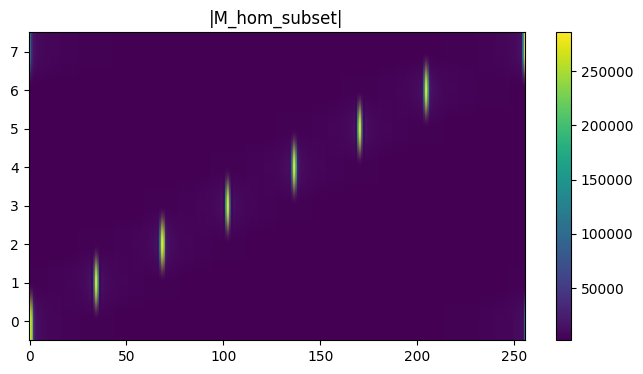

In [10]:
c_hom = jnp.full((H, W), CFG["background_speed"], dtype=jnp.float32)

t0 = time.time()
M_hom_subset = forward_measurements_subset_jit(c_hom)
M_hom_subset.block_until_ready()
t1 = time.time()

print("M_hom_subset shape:", M_hom_subset.shape, M_hom_subset.dtype)
print("first forward time (includes JIT):", t1 - t0, "sec")

plt.figure(figsize=(8, 4))
plt.imshow(np.abs(np.array(M_hom_subset)), aspect="auto", origin="lower")
plt.title("|M_hom_subset|")
plt.colorbar()
plt.show()

## 5. Опциональная инициализация от CNN
Если `init_mode = "cnn"` и checkpoint существует, можно стартовать FWI не из однородной среды, а из CNN prediction.

In [11]:
CNN_READY = False
cnn_model = None
cnn_stats = None

if CNN_CKPT_PATH.exists():
    import torch
    from torch import nn

    class ConvBlock(nn.Module):
        def __init__(self, in_ch, out_ch, stride=1):
            super().__init__()
            self.block = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=stride, padding=1),
                nn.GroupNorm(1, out_ch),
                nn.GELU(),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, stride=1, padding=1),
                nn.GroupNorm(1, out_ch),
                nn.GELU(),
            )
        def forward(self, x):
            return self.block(x)

    class SimpleUSCTBaseline(nn.Module):
        def __init__(self, in_ch=2):
            super().__init__()
            self.enc1 = ConvBlock(in_ch, 32, stride=1)
            self.enc2 = ConvBlock(32, 64, stride=2)
            self.enc3 = ConvBlock(64, 128, stride=2)
            self.enc4 = ConvBlock(128, 128, stride=2)
            self.flatten = nn.Flatten()
            self.fc = nn.Sequential(
                nn.Linear(128 * 2 * 32, 128 * 12 * 12),
                nn.GELU(),
            )
            self.dec = nn.Sequential(
                nn.ConvTranspose2d(128, 128, kernel_size=4, stride=2, padding=1),
                nn.GELU(),
                nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
                nn.GELU(),
                nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
                nn.GELU(),
                nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
                nn.GELU(),
                nn.Conv2d(16, 1, kernel_size=3, padding=1),
                nn.Sigmoid(),
            )
        def forward(self, x):
            z = self.enc1(x)
            z = self.enc2(z)
            z = self.enc3(z)
            z = self.enc4(z)
            z = self.flatten(z)
            z = self.fc(z)
            z = z.view(x.shape[0], 128, 12, 12)
            return self.dec(z)

    ckpt = torch.load(CNN_CKPT_PATH, map_location="cpu")
    cnn_model = SimpleUSCTBaseline().eval()
    cnn_model.load_state_dict(ckpt["model_state_dict"])
    cnn_stats = ckpt["stats"]
    CNN_READY = True

print("CNN_READY:", CNN_READY)
print("cnn_stats:", cnn_stats)

CNN_READY: True
cnn_stats: {'c_min': 1404.1473388671875, 'c_max': 1598.34423828125, 'x_scale_min': 290344.0, 'x_scale_max': 321105.0625, 'x_scale_mean': 296926.66734879033}


In [12]:
def prepare_cnn_input_from_npz(npz_path):
    d = np.load(npz_path)
    x_raw = d["x"].astype(np.float32)
    M_full = x_raw[0] + 1j * x_raw[1]
    M_subset = M_full[selected_source_ids]
    M_res = M_subset - np.array(M_hom_subset)

    mask = mask_selected_receivers(
        len(selected_source_ids),
        R,
        selected_source_ring_idx,
        half_width=CFG["mask_half_width"],
    )
    M_res = M_res * mask

    x = np.stack([M_res.real, M_res.imag], axis=0).astype(np.float32)
    x_scale = float(np.percentile(np.abs(x), 99.5))
    if x_scale < 1e-8:
        x_scale = 1.0
    x = x / x_scale
    return x

def get_cnn_init_c(npz_path):
    if not CNN_READY:
        raise RuntimeError("CNN checkpoint is not ready")
    import torch

    x = prepare_cnn_input_from_npz(npz_path)
    x_t = torch.from_numpy(x).unsqueeze(0)

    with torch.no_grad():
        pred_norm = cnn_model(x_t)[0, 0].numpy()

    c_pred = pred_norm * (cnn_stats["c_max"] - cnn_stats["c_min"]) + cnn_stats["c_min"]
    return c_pred.astype(np.float32)

In [13]:
def z_to_c(z_low):
    z_up = resize(z_low, (H, W), method="linear", antialias=False)
    return CFG["background_speed"] + CFG["amplitude_limit"] * jnp.tanh(z_up)

def c_to_z_low(c_map, low_h, low_w):
    c_clip = np.clip(
        c_map,
        CFG["background_speed"] - 0.999 * CFG["amplitude_limit"],
        CFG["background_speed"] + 0.999 * CFG["amplitude_limit"],
    )
    u = (c_clip - CFG["background_speed"]) / CFG["amplitude_limit"]
    z_full = np.arctanh(u).astype(np.float32)
    z_low = resize(jnp.array(z_full), (low_h, low_w), method="linear", antialias=False)
    return jnp.array(z_low, dtype=jnp.float32)

def smoothness_penalty(c_map):
    dy = c_map[1:, :] - c_map[:-1, :]
    dx_ = c_map[:, 1:] - c_map[:, :-1]
    return jnp.mean(dy**2) + jnp.mean(dx_**2)

def make_loss_fn(M_target_subset_complex, mask):
    mask_j = jnp.array(mask, dtype=jnp.float32)
    M_target_j = jnp.array(M_target_subset_complex, dtype=jnp.complex64)
    M_hom_j = jnp.array(np.array(M_hom_subset), dtype=jnp.complex64)

    def loss_fn(z_low):
        c_map = z_to_c(z_low)
        M_pred = forward_measurements_subset_jit(c_map)
        M_pred_res = M_pred - M_hom_j
        M_target_res = M_target_j - M_hom_j
        diff = M_pred_res - M_target_res
        data_term = jnp.sum(mask_j * (jnp.abs(diff) ** 2)) / (jnp.sum(mask_j) + 1e-8)
        l2_term = jnp.mean(z_low**2)
        smooth_term = smoothness_penalty(c_map)
        return data_term + CFG["lambda_l2"] * l2_term + CFG["lambda_smooth"] * smooth_term

    return loss_fn

In [14]:
def adam_optimize(loss_fn, z0, num_steps, lr, beta1=0.9, beta2=0.999, eps=1e-8, stage_name=""):
    z = z0
    m = jnp.zeros_like(z)
    v = jnp.zeros_like(z)

    loss_and_grad = jit(value_and_grad(loss_fn))
    history = []

    for t in range(1, num_steps + 1):
        loss_val, grad = loss_and_grad(z)
        m = beta1 * m + (1.0 - beta1) * grad
        v = beta2 * v + (1.0 - beta2) * (grad ** 2)
        m_hat = m / (1.0 - beta1 ** t)
        v_hat = v / (1.0 - beta2 ** t)
        z = z - lr * m_hat / (jnp.sqrt(v_hat) + eps)
        history.append(float(loss_val))

        if t == 1 or t % 10 == 0 or t == num_steps:
            print(f"{stage_name} step {t:4d} | loss={float(loss_val):.6f}")

    return z, history

def upsample_z(z_old, new_h, new_w):
    z_new = resize(z_old, (new_h, new_w), method="linear", antialias=False)
    return z_new.astype(jnp.float32)

In [15]:
def reconstruct_one_example_fwi(npz_path: Path):
    d = np.load(npz_path)

    x = d["x"].astype(np.float32)
    c_true = d["c"].astype(np.float32)
    M_full = x[0] + 1j * x[1]
    M_target_subset = M_full[selected_source_ids]

    mask = mask_selected_receivers(
        len(selected_source_ids),
        R,
        selected_source_ring_idx,
        half_width=CFG["mask_half_width"],
    )
    loss_fn = make_loss_fn(M_target_subset, mask)

    stage_histories = []

    z = None
    init_c = None
    if CFG["init_mode"] == "cnn" and CNN_READY:
        init_c = get_cnn_init_c(npz_path)

    t0 = time.time()
    for stage_id, stage in enumerate(CFG["stages"], start=1):
        sh, sw = stage["lowres_h"], stage["lowres_w"]

        if z is None:
            if init_c is None:
                z = jnp.zeros((sh, sw), dtype=jnp.float32)
            else:
                z = c_to_z_low(init_c, sh, sw)
        else:
            z = upsample_z(z, sh, sw)

        z, hist = adam_optimize(
            loss_fn,
            z,
            num_steps=stage["num_steps"],
            lr=stage["lr"],
            beta1=CFG["beta1"],
            beta2=CFG["beta2"],
            eps=CFG["adam_eps"],
            stage_name=f"[stage {stage_id}: {sh}x{sw}]",
        )
        z.block_until_ready()
        stage_histories.append(hist)

    c_pred = np.array(z_to_c(z))
    t1 = time.time()

    out = {
        "path": str(npz_path),
        "c_true": c_true,
        "c_pred": c_pred,
        "history": [v for hist in stage_histories for v in hist],
        "stage_histories": stage_histories,
        "runtime_sec": t1 - t0,
    }

    if init_c is not None:
        out["init_c"] = init_c

    return out

In [16]:
example_ids = CFG["example_indices_from_test"][:CFG["num_examples_to_run"]]
example_paths = [test_files[i] for i in example_ids]

print("example_paths:")
for p in example_paths:
    print(p)

example_paths:
/workspace/usct_dataset_v2/test/sample_00000.npz
/workspace/usct_dataset_v2/test/sample_00001.npz
/workspace/usct_dataset_v2/test/sample_00002.npz


[stage 1: 16x16] step    1 | loss=5729258.000000
[stage 1: 16x16] step   10 | loss=2215233.500000
[stage 1: 16x16] step   20 | loss=1852602.500000
[stage 1: 16x16] step   30 | loss=1562794.875000
[stage 1: 16x16] step   40 | loss=1414957.125000
[stage 1: 16x16] step   50 | loss=1334687.875000
[stage 1: 16x16] step   60 | loss=1292019.750000
[stage 1: 16x16] step   70 | loss=1270033.750000
[stage 1: 16x16] step   80 | loss=1258293.500000
[stage 1: 16x16] step   90 | loss=1250312.375000
[stage 1: 16x16] step  100 | loss=1245243.250000
[stage 1: 16x16] step  110 | loss=1241633.625000
[stage 1: 16x16] step  120 | loss=1238953.500000
[stage 2: 24x24] step    1 | loss=1552657.875000
[stage 2: 24x24] step   10 | loss=1219953.250000
[stage 2: 24x24] step   20 | loss=1050573.875000
[stage 2: 24x24] step   30 | loss=970456.187500
[stage 2: 24x24] step   40 | loss=924775.687500
[stage 2: 24x24] step   50 | loss=896716.562500
[stage 2: 24x24] step   60 | loss=878014.562500
[stage 2: 24x24] step   

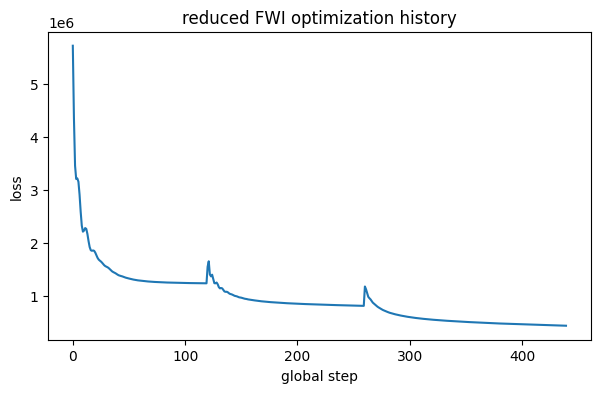

In [17]:
result0 = reconstruct_one_example_fwi(example_paths[0])

print("runtime_sec:", result0["runtime_sec"])
print("final loss:", result0["history"][-1])

plt.figure(figsize=(7, 4))
plt.plot(result0["history"])
plt.xlabel("global step")
plt.ylabel("loss")
plt.title("reduced FWI optimization history")
plt.show()

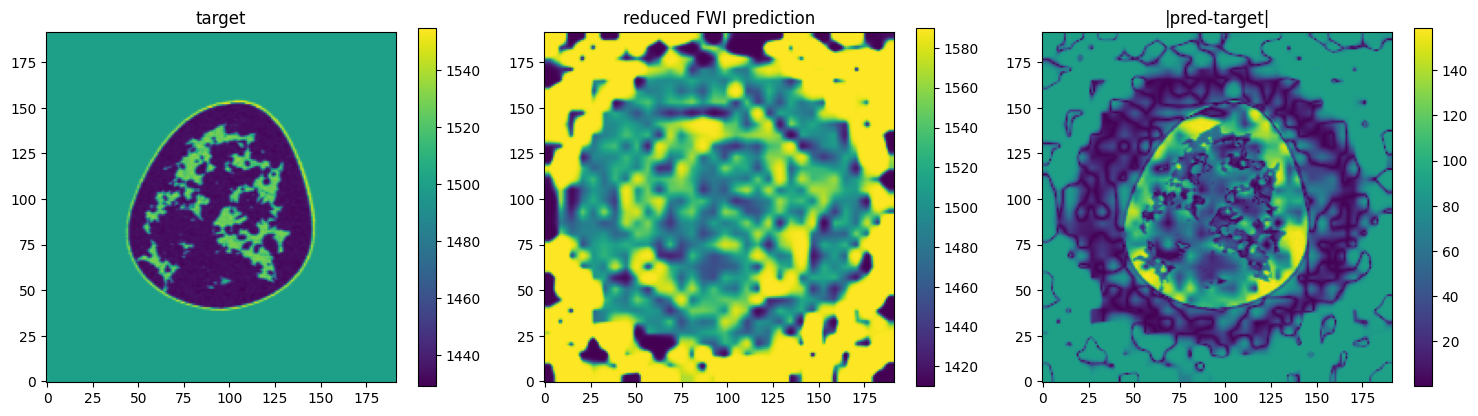

In [18]:
def show_reconstruction(result):
    if "init_c" in result:
        fig, ax = plt.subplots(1, 4, figsize=(20, 4))
        im0 = ax[0].imshow(result["c_true"], origin="lower")
        ax[0].set_title("target")
        plt.colorbar(im0, ax=ax[0])

        im1 = ax[1].imshow(result["init_c"], origin="lower")
        ax[1].set_title("initialization")
        plt.colorbar(im1, ax=ax[1])

        im2 = ax[2].imshow(result["c_pred"], origin="lower")
        ax[2].set_title("reduced FWI prediction")
        plt.colorbar(im2, ax=ax[2])

        im3 = ax[3].imshow(np.abs(result["c_pred"] - result["c_true"]), origin="lower")
        ax[3].set_title("|pred-target|")
        plt.colorbar(im3, ax=ax[3])
    else:
        fig, ax = plt.subplots(1, 3, figsize=(15, 4))
        im0 = ax[0].imshow(result["c_true"], origin="lower")
        ax[0].set_title("target")
        plt.colorbar(im0, ax=ax[0])

        im1 = ax[1].imshow(result["c_pred"], origin="lower")
        ax[1].set_title("reduced FWI prediction")
        plt.colorbar(im1, ax=ax[1])

        im2 = ax[2].imshow(np.abs(result["c_pred"] - result["c_true"]), origin="lower")
        ax[2].set_title("|pred-target|")
        plt.colorbar(im2, ax=ax[2])

    plt.tight_layout()
    plt.show()

show_reconstruction(result0)

In [19]:
results = []
for p in example_paths:
    print("=" * 80)
    print("reconstructing:", p)
    res = reconstruct_one_example_fwi(p)
    results.append(res)
    print("runtime_sec:", res["runtime_sec"])
    print("final loss:", res["history"][-1])

reconstructing: /workspace/usct_dataset_v2/test/sample_00000.npz
[stage 1: 16x16] step    1 | loss=5729258.000000
[stage 1: 16x16] step   10 | loss=2215233.500000
[stage 1: 16x16] step   20 | loss=1852602.500000
[stage 1: 16x16] step   30 | loss=1562794.875000
[stage 1: 16x16] step   40 | loss=1414957.125000
[stage 1: 16x16] step   50 | loss=1334687.875000
[stage 1: 16x16] step   60 | loss=1292019.750000
[stage 1: 16x16] step   70 | loss=1270033.750000
[stage 1: 16x16] step   80 | loss=1258293.500000
[stage 1: 16x16] step   90 | loss=1250312.375000
[stage 1: 16x16] step  100 | loss=1245243.250000
[stage 1: 16x16] step  110 | loss=1241633.625000
[stage 1: 16x16] step  120 | loss=1238953.500000
[stage 2: 24x24] step    1 | loss=1552657.875000
[stage 2: 24x24] step   10 | loss=1219953.250000
[stage 2: 24x24] step   20 | loss=1050573.875000
[stage 2: 24x24] step   30 | loss=970456.187500
[stage 2: 24x24] step   40 | loss=924775.687500
[stage 2: 24x24] step   50 | loss=896716.562500
[stage 

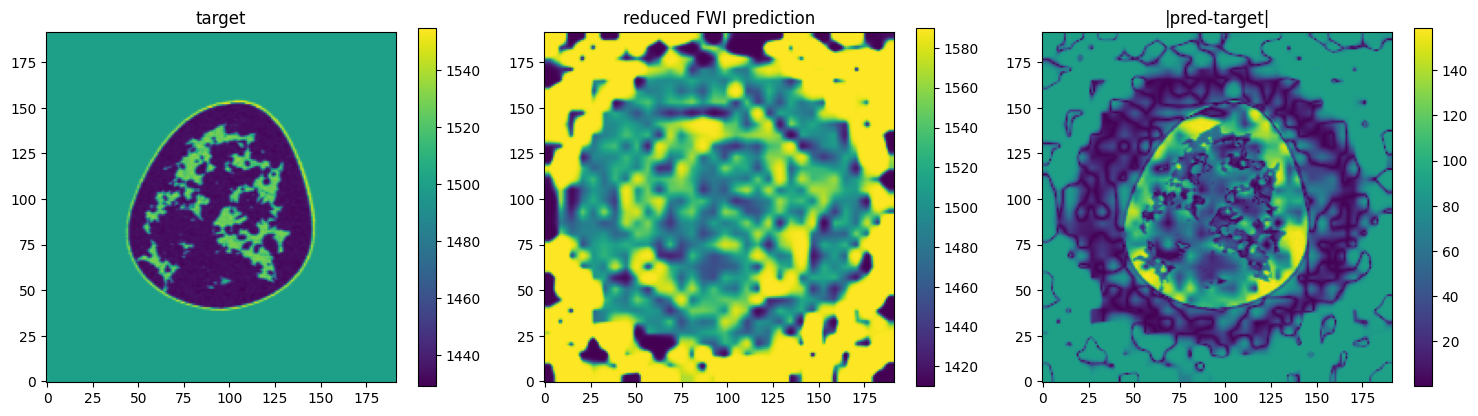

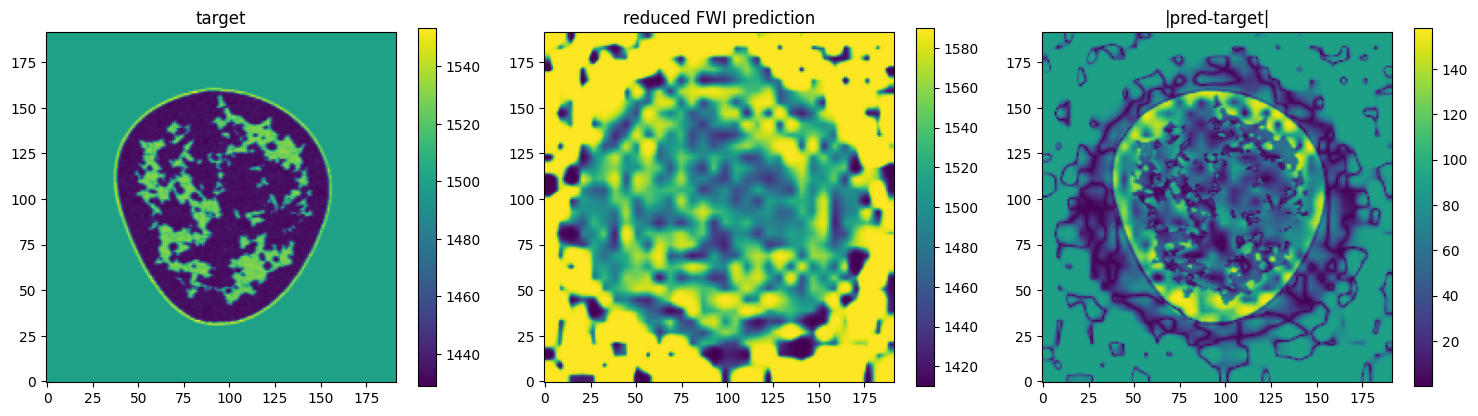

In [ ]:
for res in results:
    show_reconstruction(res)

In [ ]:
data_range = float(
    np.max([r["c_true"].max() for r in results]) - np.min([r["c_true"].min() for r in results])
)

metrics_list = []
for i, res in enumerate(results):
    m = compute_metrics(res["c_pred"], res["c_true"], data_range=data_range)
    m["index"] = i
    m["path"] = res["path"]
    m["runtime_sec"] = float(res["runtime_sec"])
    metrics_list.append(m)

summary = {}
for key in metrics_list[0].keys():
    if key in ("index", "path"):
        continue
    vals = [m[key] for m in metrics_list]
    summary[f"{key}_mean"] = float(np.mean(vals))
    summary[f"{key}_std"] = float(np.std(vals))

print("REDUCED FWI SUMMARY")
print(json.dumps(summary, ensure_ascii=False, indent=2))

In [ ]:
RUN_NAME = CFG["save_run_name"]
OUT_DIR = Path("/workspace/reference_points") / RUN_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)

config_to_save = {
    "run_name": RUN_NAME,
    "description": "Reduced FWI baseline with residual objective, source subset, coarse-to-fine optimization, optional CNN init",
    "num_examples": len(results),
    "example_indices_from_test": example_ids,
    "cfg": CFG,
    "H": H,
    "W": W,
    "S_full": S_full,
    "S_used": len(selected_source_ids),
    "R": R,
    "selected_source_ids": selected_source_ids.tolist(),
    "selected_source_ring_idx": selected_source_ring_idx.tolist(),
    "freq_hz": float(freq_hz),
    "dx": [float(x) for x in dx],
}

with open(OUT_DIR / "config.json", "w", encoding="utf-8") as f:
    json.dump(config_to_save, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "metrics_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

with open(OUT_DIR / "metrics_full.json", "w", encoding="utf-8") as f:
    json.dump(metrics_list, f, ensure_ascii=False, indent=2)

for i, res in enumerate(results):
    payload = {
        "c_true": res["c_true"].astype(np.float32),
        "c_pred": res["c_pred"].astype(np.float32),
        "history": np.array(res["history"], dtype=np.float32),
        "runtime_sec": np.array([res["runtime_sec"]], dtype=np.float32),
    }
    if "init_c" in res:
        payload["init_c"] = res["init_c"].astype(np.float32)
    np.savez_compressed(OUT_DIR / f"reconstruction_{i:02d}.npz", **payload)

print("saved results to:", OUT_DIR)